# Polydisperse hard-sphere–Yukawa: from a size distribution to $I(Q)$

Exact scattered intensity for a **polydisperse interacting** system, with no decoupling
or local-monodisperse approximation:

$$I(Q)=\sum_{ij}\sqrt{n_i n_j}\,F_i(Q)F_j(Q)\,S^{\rm AL}_{ij}(Q)$$

The partial structure factors $S^{\rm AL}_{ij}$ come from the analytic $N$-species
one-Yukawa MSA solution (`polydisperse_yukawa_msa.py` + `polydisperse_yukawa_sq.py`),
validated to $\le3\times10^{-10}$ against SASfit's own `liboneyukawa` at $N=1$ and,
at $N>1$, against an independent numerical OZ solver — see
`docs/polydisperse_yukawa_spec.md` §7h–7l.

Scope: $\delta_i = 1$ (common Yukawa coupling, arbitrary **size** polydispersity).
Charge polydispersity is still an open item.

In [1]:
import numpy as np, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

from polydisperse_yukawa_sas import (LogNormal, SchulzZimm, Sphere, CoreShell,
                                     PolydisperseYukawaSAS, discretize, moment_report)

# a concrete system: 50 A radius, 20% volume fraction, screened-Coulomb repulsion
R0, PHI = 50.0, 0.20          # A, -
ZS, K   = 6.0, 1.0            # dimensionless Z = z*sigma_ref, and contact strength
Z = ZS/(2*R0)                 # z is an inverse LENGTH in the same units as R
Q = np.geomspace(2e-3, 0.13, 200)   # A^-1

## 1. Discretizing the size distribution

Each distribution is integrated with **its own natural quadrature** — Gauss–Legendre in
log space for log-normal, generalised Gauss–Laguerre for Schulz–Zimm — so few bins
reproduce the moments accurately. This matters because $I(Q\to0)$ depends on
$\langle R^3\rangle^2$ and $\langle R^6\rangle$.

Always check with `moment_report`: `nsig` (the truncation width) trades moment fidelity
against numerical dynamic range, and there is no good setting above rel.sd $\approx0.4$.
See the table in the module docstring.

In [2]:
for d in [LogNormal(R0, 0.25), SchulzZimm(R0, relsd=0.25)]:
    R, w = discretize(d, nbins=16)
    print(d)
    for n, (num, ex, rel) in moment_report(d, R, w).items():
        print(f"   <R^{n}>  discretized {num:.8g}   exact {ex:.8g}   rel {rel:.1e}")

LogNormal(R0=50, sigma_ln=0.25, relsd=0.254)
   <R^1>  discretized 51.587147   exact 51.58717   rel 4.6e-07
   <R^2>  discretized 2832.8635   exact 2832.8711   rel 2.7e-06
   <R^3>  discretized 165596.45   exact 165598.09   rel 9.9e-06
   <R^6>  discretized 4.8117222e+10   exact 4.8128388e+10   rel 2.3e-04
SchulzZimm(Rmean=50, z=15, relsd=0.250)
   <R^1>  discretized 50   exact 50   rel 5.7e-16
   <R^2>  discretized 2656.25   exact 2656.25   rel 1.7e-16
   <R^3>  discretized 149414.06   exact 149414.06   rel 3.1e-15
   <R^6>  discretized 3.6386847e+10   exact 3.6386847e+10   rel 3.1e-15


## 2. Partial structure factors, and how polydispersity reshapes $S(Q)$

bin diameters (A): [ 31.2  43.8  74.2 134.8 228.5 320.8]
S positive-definite at every Q: True


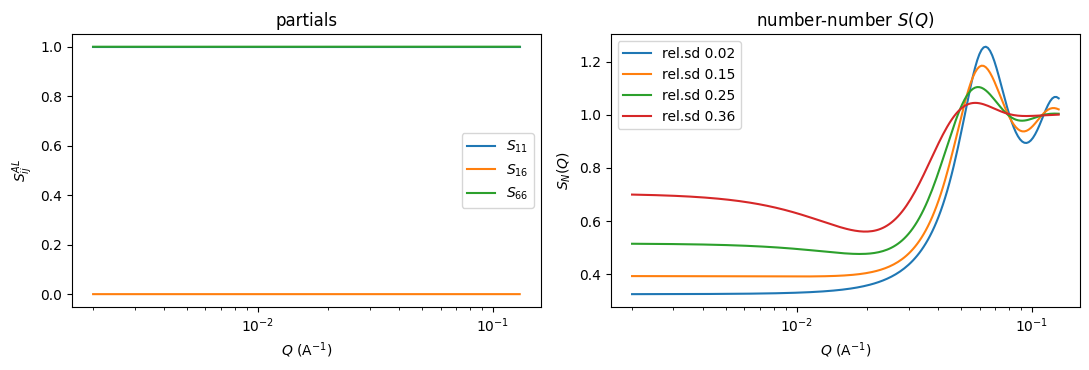

In [3]:
m = PolydisperseYukawaSAS(LogNormal(R0, 0.25), PHI, Z, K, Sphere(), nbins=6)
S = m.S_partials(Q)                      # (nQ, N, N)
print("bin diameters (A):", np.round(m.sigma, 1))
print("S positive-definite at every Q:",
      all(np.min(np.linalg.eigvalsh(S[i])) > 0 for i in range(len(Q))))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for (i, j) in [(0,0), (0,5), (5,5)]:
    ax[0].plot(Q, S[:, i, j], label=f"$S_{{{i+1}{j+1}}}$")
ax[0].set_xscale("log"); ax[0].set_xlabel("$Q$ (A$^{-1}$)"); ax[0].set_ylabel("$S_{ij}^{AL}$")
ax[0].legend(); ax[0].set_title("partials")
for s in [0.02, 0.15, 0.25, 0.35]:
    mm = PolydisperseYukawaSAS(LogNormal(R0, s), PHI, Z, K, Sphere(), nbins=14)
    ax[1].plot(Q, mm.S_number(Q), label=f"rel.sd {np.sqrt(np.exp(s**2)-1):.2f}")
ax[1].set_xscale("log"); ax[1].set_xlabel("$Q$ (A$^{-1}$)"); ax[1].set_ylabel("$S_N(Q)$")
ax[1].legend(); ax[1].set_title("number-number $S(Q)$")
fig.tight_layout()

## 3. $I(Q)$, and how wrong SASfit's approximations are

SASfit implements **six** ways to fold a structure factor into a polydisperse
intensity, all transcribed here from its own manual
(`doc/manual/SASfit_ch3.tex`, "Methods to include structure factors"). The GUI
(`sasfit_analytical.tcl`) exposes the first five as radiobuttons; the sixth, the
van der Waals one-fluid approximation, is documented but not among them.

| # | approach | expression |
|---|---|---|
| 0 | monodisperse | $n\langle F^2\rangle S(Q)$ |
| 1 | decoupling (Kotlarchyk–Chen 1983) | $n\{\langle F^2\rangle+\langle F\rangle^2[S(Q)-1]\}$ |
| 2 | local monodisperse (Pedersen 1994) | $n\sum_i w_iF_i^2\,S(Q;R_i)$ |
| 3 | partial structure factors | $n\{\langle F^2\rangle+\sum_{ij}w_iw_jF_iF_j[S_{ij}-1]\}$ |
| 4 | scaling (Gazzillo et al. 1999) | as 3, each term $\times\,\bar V_{ij}/V_{\rm av}$ |
| 5 | van der Waals one-fluid | as 4, normalised by $\langle\bar V\rangle$ |

The crucial point about 3–5: their "$S_{ij}$" is **not** the true partial
structure factor. It is the *monodisperse* $S(Q)$ evaluated at the mean radius
$(R_i+R_j)/2$ — precisely the substitution the exact solution removes. So this
comparison isolates the cost of that one approximation.


decoupling overestimates I(Q->0) by 2.01x


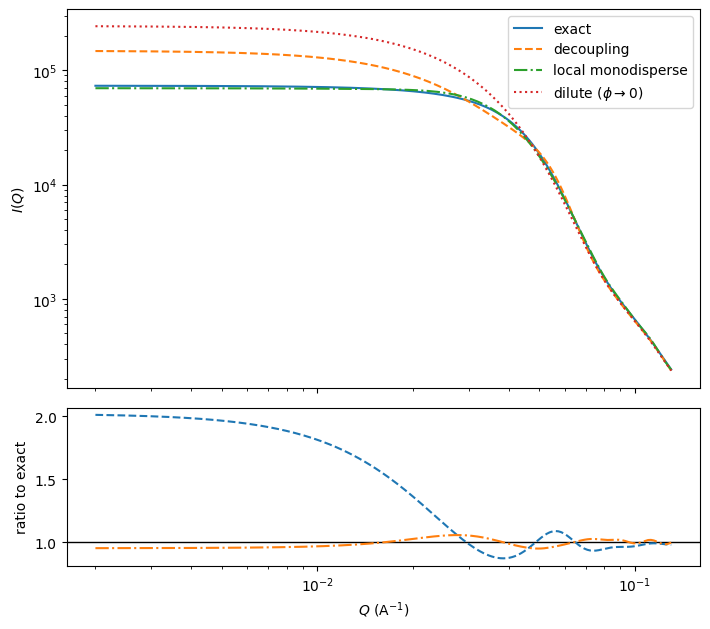

In [4]:
m = PolydisperseYukawaSAS(LogNormal(R0, 0.25), PHI, Z, K, Sphere(), nbins=18)
Ie, Id = m.I_exact(Q), m.I_dilute(Q)
Ida, Il = m.I_decoupling(Q), m.I_lma(Q)

fig, ax = plt.subplots(2, 1, figsize=(7.2, 6.4), sharex=True,
                       gridspec_kw={"height_ratios":[2.4,1]})
ax[0].plot(Q, Ie,  label="exact")
ax[0].plot(Q, Ida, "--", label="decoupling")
ax[0].plot(Q, Il,  "-.", label="local monodisperse")
ax[0].plot(Q, Id,  ":",  label=r"dilute ($\phi\to0$)")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_ylabel("$I(Q)$"); ax[0].legend()
ax[1].axhline(1, color="k", lw=1)
ax[1].plot(Q, Ida/Ie, "--"); ax[1].plot(Q, Il/Ie, "-.")
ax[1].set_xscale("log"); ax[1].set_xlabel("$Q$ (A$^{-1}$)"); ax[1].set_ylabel("ratio to exact")
fig.tight_layout()
print(f"decoupling overestimates I(Q->0) by {Ida[0]/Ie[0]:.2f}x")

### A metric warning worth taking seriously

Do **not** score these with a plain max-relative-error over all $Q$. $I(Q)$ spans
decades and passes through form-factor minima where it nearly vanishes; any ratio
explodes there, and those minima are *deepest at low polydispersity*, so the naive
metric shows a spurious error floor exactly where both approximations must become
exact. Restrict to the $Q$ range carrying signal.

In [5]:
def err(Ie, Ia, frac=0.01):
    """Restrict to the Q range carrying signal -- see the warning below."""
    m = Ie > frac*Ie[0]
    return np.max(np.abs(Ia[m]/Ie[m] - 1.0))

methods = [("0 monodisperse",   "I_monodisperse"),
           ("1 decoupling",     "I_decoupling"),
           ("2 local mono.",    "I_lma"),
           ("3 partial SF",     "I_partial_sf"),
           ("4 scaling",        "I_scaling"),
           ("5 vdW one-fluid",  "I_vdw1")]

qq = np.geomspace(3e-3, 0.10, 30)
print("worst error in I(Q), %, vs exact")
print(f"{'rel.sd':>7}" + "".join(f"{n.split()[0]:>9}" for n, _ in methods))
for s in [0.03, 0.10, 0.20, 0.30]:
    mm = PolydisperseYukawaSAS(LogNormal(R0, s), PHI, Z, K, Sphere(), nbins=10)
    Iex = mm.I_exact(qq)
    row = []
    for _, fn in methods:
        try:
            row.append(f"{100*err(Iex, getattr(mm, fn)(qq)):9.1f}")
        except Exception:
            row.append(f"{'undef':>9}")
    print(f"{np.sqrt(np.exp(s**2)-1):7.3f}" + "".join(row))


worst error in I(Q), %, vs exact
 rel.sd        0        1        2        3        4        5


  0.030      1.3      1.9      1.0      1.8      0.3      0.3


  0.100     11.1     20.0      5.6     19.5      3.5      2.6


  0.202     16.8     70.9      9.6     69.4     12.1      9.5


  0.307     28.5    124.8     13.1    123.0     20.6     19.4


Three things stand out.

**"Partial structure factors" is no better than decoupling.** The two curves lie
almost on top of each other at every polydispersity. The name promises the
$S_{ij}$ machinery, but substituting the monodisperse $S$ at the mean radius
throws away exactly what makes $S_{ij}$ different — so it inherits decoupling's
failure mode wholesale. If you are choosing between the two in SASfit, the
choice barely matters; both are wrong by >100% at rel.sd 0.31.

**The volume weighting is what actually helps.** Options 4 and 5 differ from 3
only by the factor $\bar V_{ij}/V_{\rm av}$ (or $/\langle\bar V\rangle$), and
that single factor drops the error from ~125% to ~20%. Gazzillo's scaling
argument is doing real work.

**Local monodisperse wins throughout**, but it can be *undefined*, not merely
approximate: it needs an auxiliary monodisperse MSA solution at every bin
diameter, and the small-$\sigma$ bins correspond to weak screening
($z\sigma_i\sim1$) at the full volume fraction, where the one-Yukawa MSA has no
physical root. The exact calculation is perfectly well-posed on the same
parameters. Options 3–5 hit the same wall for the smallest *pairs*. Each method
reports the affected weight and raises rather than returning a quietly-wrong
curve.


## 4. Core-shell particles

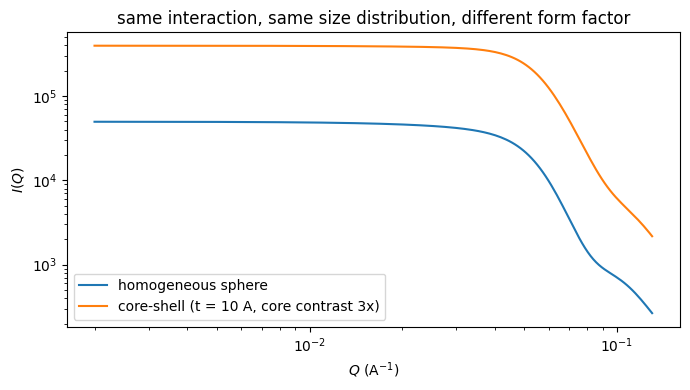

In [6]:
d = SchulzZimm(R0, relsd=0.20)
plain = PolydisperseYukawaSAS(d, PHI, Z, K, Sphere(drho=1.0), nbins=16)
cs    = PolydisperseYukawaSAS(d, PHI, Z, K,
            CoreShell(rho_core=4.0, rho_shell=1.0, rho_solvent=0.0, thickness=10.0),
            nbins=16)
plt.figure(figsize=(7,4))
plt.loglog(Q, plain.I_exact(Q), label="homogeneous sphere")
plt.loglog(Q, cs.I_exact(Q),    label="core-shell (t = 10 A, core contrast 3x)")
plt.xlabel("$Q$ (A$^{-1}$)"); plt.ylabel("$I(Q)$"); plt.legend()
plt.title("same interaction, same size distribution, different form factor")
plt.tight_layout()

The hard core and the Yukawa act on the **outer** diameter, so both systems share
identical $S_{ij}(Q)$ — only $F_i(Q)$ differs. That separation is exactly what makes
the exact expression useful: structure and form factor stay independent, which the
decoupling approximation destroys by folding polydispersity into a single $\beta(Q)$.

## Where this sits

- `polydisperse_yukawa_sas.py` — this layer (distributions, form factors, exact $I(Q)$, both approximations)
- `polydisperse_yukawa_msa.py` / `polydisperse_yukawa_sq.py` — closure and $S_{ij}(Q)$
- `sas_validation.py` — monodisperse limit, dilute limit, nbins convergence, core-shell sanity, $S_{ij}$ consistency
- `README_polydisperse_yukawa.md` — file guide and the list of known misprints in Blum & Hernando (2002)

Still open: $\delta_i\neq1$ (charge polydispersity), $M>1$ (multi-Yukawa), complex $z_n$.

## 5. Does the ranking hold for other interactions?

Everything above is one interaction: a repulsive Yukawa. Two independent checks
— an **attractive** Yukawa ($K<0$), and the **Robertus multicomponent sticky
hard sphere** model, which is SASfit's own C engine
(`src/plugins/robertus_shs/`, after Robertus et al., *J. Chem. Phys.* **90**,
4482 (1989)) wrapped with ctypes. Nothing in the Blum–Hernando machinery is
involved in that second one, and both run through byte-identical approximation
code (`polydisperse_sas_base.py`), so any difference is physics.


In [7]:
from robertus_shs_sas import RobertusSHSSAS

def table(m, qq):
    Ie = m.I_exact(qq)
    out = []
    for _, fn in methods:
        try:
            out.append(f"{100*err(Ie, getattr(m, fn)(qq)):9.1f}")
        except Exception:
            out.append(f"{'undef':>9}")
    return "".join(out)

qq = np.geomspace(3e-3, 0.10, 30)
hdr = f"{'rel.sd':>7}" + "".join(f"{n.split()[0]:>9}" for n, _ in methods)
for lab, build in [
    ("attractive Yukawa K=+1",
     lambda s: PolydisperseYukawaSAS(LogNormal(R0, s), PHI, Z, +1.0, Sphere(), nbins=12)),
    ("repulsive Yukawa  K=-1",
     lambda s: PolydisperseYukawaSAS(LogNormal(R0, s), PHI, Z, -1.0, Sphere(), nbins=12)),
    ("sticky hard spheres tau=0.2",
     lambda s: RobertusSHSSAS(2*R0, np.sqrt(np.exp(s**2)-1), PHI, 0.2, Sphere(), nbins=12)),
]:
    print(f"\n{lab}"); print(hdr)
    for s in [0.03, 0.10, 0.20, 0.30]:
        print(f"{np.sqrt(np.exp(s**2)-1):7.3f}" + table(build(s), qq))


repulsive Yukawa  K=+1
 rel.sd        0        1        2        3        4        5


  0.030      1.3      1.8      1.0      1.8      0.3      0.2


  0.100     11.1     19.9      5.2     19.4      3.5      2.6


  0.202     16.9     71.0      5.3     69.6     12.2      9.5


  0.307     28.8    125.2      9.0    123.5     20.7     19.3

attractive Yukawa K=-1
 rel.sd        0        1        2        3        4        5


...

  0.100      9.4     35.2      7.5     35.5      1.6      7.9


  0.202     25.1     98.8     21.9     99.7      4.8     23.4


  0.307     39.2    141.5     33.3    142.5      7.2     39.0

sticky hard spheres tau=0.2
 rel.sd        0        1        2        3        4        5


  0.030      0.7      0.4      1.0      0.4      0.1      0.1
  0.100      7.3      4.7      5.6      4.4      1.0      1.5
  0.202     19.3     16.4      4.2     15.0      4.0      5.5


  0.307     26.8     29.4      7.5     27.0      8.8     11.4


**The ranking is not universal — it depends on the interaction.**

Note the sign convention first: the MSA sets $c=-\beta U$ outside the core, so
$K>0$ is an **attraction** and $K<0$ a **repulsion** (check: at $\varphi=0.1$,
$K=+1$ gives $g(\sigma^+)=2.13$ and $S(0)=0.636$ against hard-sphere values
$1.296$ and $0.456$ — contact enhanced, compressibility raised).

For the *attractive* Yukawa, local monodisperse wins (9% at rel.sd 0.31) and
Gazzillo's scaling is twice as bad (21%). Flip the sign of $K$ and the order
reverses: for the *repulsive* Yukawa scaling becomes far the best (7%) while
local monodisperse degrades to 33%. Sticky hard spheres — an attraction —
behave like the attractive Yukawa, as they should.

This matters because the commonest strongly interacting SANS system, a
charge-stabilised colloid, is **repulsive**. So "use the local monodisperse
approximation" is well founded for attractive systems but wrong for the
commoner one; there, scaling is better by about a factor of four.

**What does hold everywhere:** decoupling and "partial structure factors" are
indistinguishable in all three interactions, at every polydispersity. That
coincidence is structural, not accidental — both discard the true $S_{ij}$ in
the same way — and it means the extra cost of the double integral in option 3
buys nothing at all over option 1.
